# 이미지 캡셔닝(Image Captioning)

## 데이터 다운로드

- kaggle **[Flickr 8k Dataset](https://www.kaggle.com/datasets/adityajn105/flickr8k/data)**에서 다운로드 가능

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

In [ ]:
!robocopy "C:\Users\user\.cache\kagglehub\datasets\adityajn105\flickr8k\versions\1" "dataset" /e

In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, Layer
#from tensorflow.keras.layers import  GlobalAveragePooling2D, Activation
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
#from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.regularizers import l2

#from tensorflow.keras.optimizers import Adam
#from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap
import pickle

plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

c:\Users\user\anaconda3\envs\tf-gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 데이터 준비

In [2]:
image_path = './dataset/images'

In [3]:
data = pd.read_csv("./dataset/captions.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [36]:
def readImage(path,img_size=224):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    
    return img

def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize = (20 , 30))
    n = 0
    for i in range(len(temp_df)):
        n+=1
        plt.subplot(7, 4, n)
        plt.subplots_adjust(hspace = 0.7, wspace = 0.3)
        image = readImage(f"./dataset/images/{temp_df.image[i]}")
        plt.imshow(image)
        plt.title("\n".join(wrap(temp_df.caption[i], 20)))
        plt.axis("off")

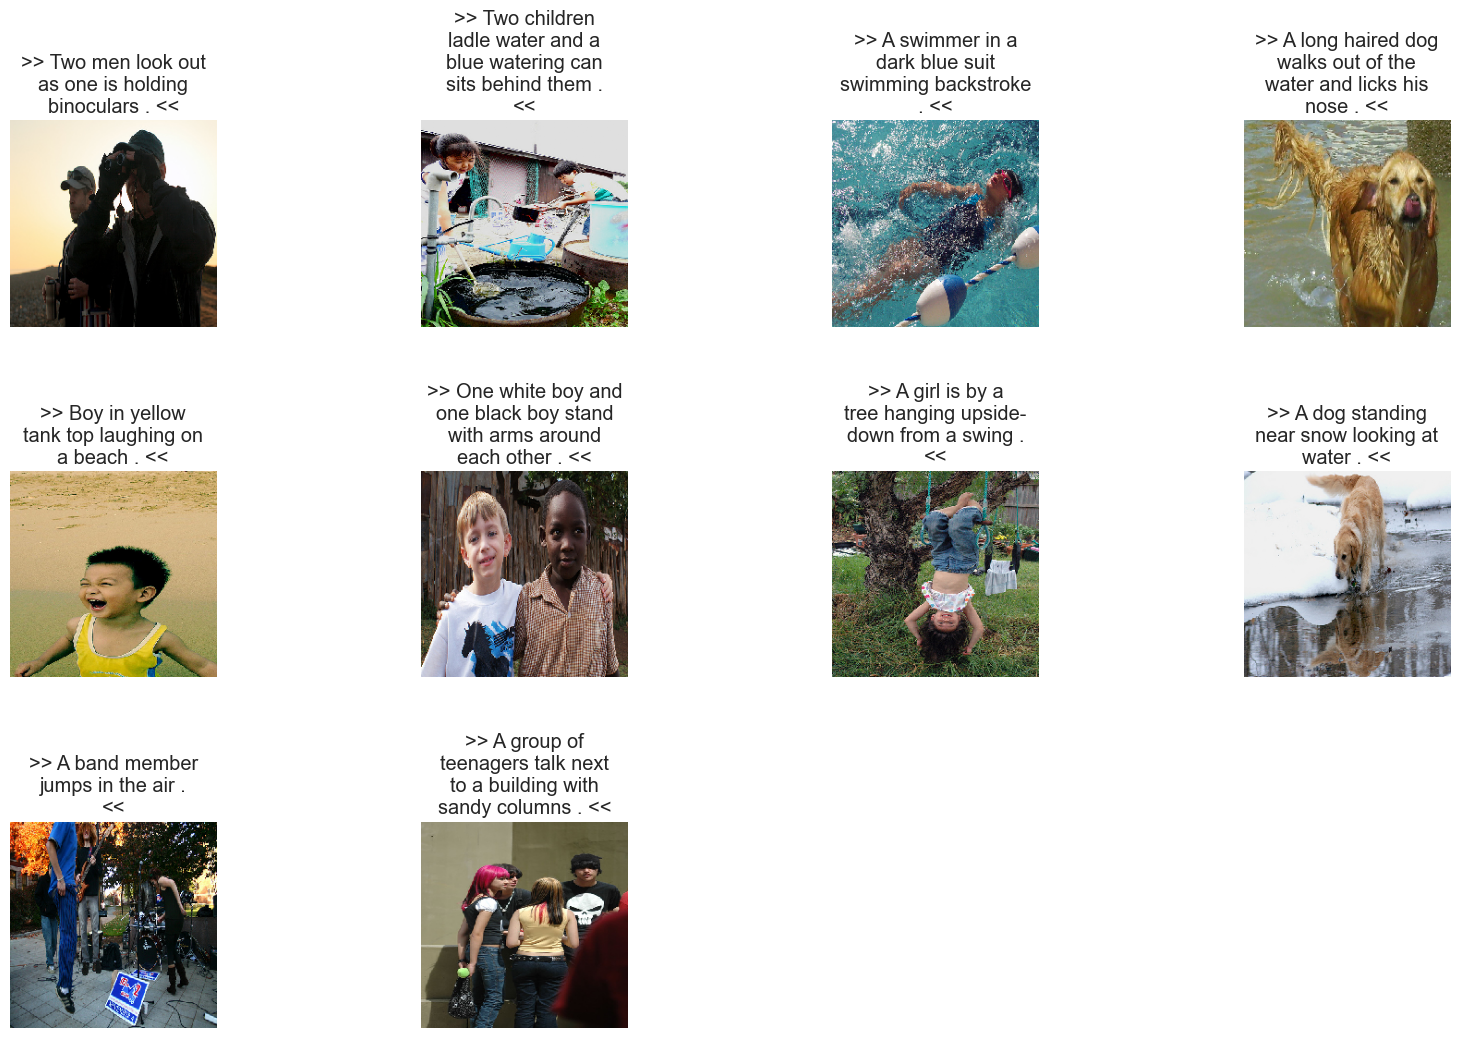

In [37]:
display_images(data.sample(10))

In [6]:
data['caption'] = ">> "+data['caption']+" <<"
captions = data['caption'].tolist()
captions[:10]

['>> A child in a pink dress is climbing up a set of stairs in an entry way . <<',
 '>> A girl going into a wooden building . <<',
 '>> A little girl climbing into a wooden playhouse . <<',
 '>> A little girl climbing the stairs to her playhouse . <<',
 '>> A little girl in a pink dress going into a wooden cabin . <<',
 '>> A black dog and a spotted dog are fighting <<',
 '>> A black dog and a tri-colored dog playing with each other on the road . <<',
 '>> A black dog and a white dog with brown spots are staring at each other in the street . <<',
 '>> Two dogs of different breeds looking at each other on the road . <<',
 '>> Two dogs on pavement moving toward each other . <<']

In [7]:
# 어휘 사전 생성
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

In [8]:
tokenizer.texts_to_sequences([captions[1]])[0]

[1, 17, 314, 62, 1, 194, 115]

In [9]:
def idx_to_word(integer,tokenizer):
    
    for word, index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None

In [10]:
# 데이터를 train, test로 분리
images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.80*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

train.head()

,image,caption
0,1000268201_693b08cb0e.jpg,>> A child in a pink dress is climbing up a se...
1,1000268201_693b08cb0e.jpg,>> A girl going into a wooden building . <<
2,1000268201_693b08cb0e.jpg,>> A little girl climbing into a wooden playho...
3,1000268201_693b08cb0e.jpg,>> A little girl climbing the stairs to her pl...
4,1000268201_693b08cb0e.jpg,>> A little girl in a pink dress going into a ...


In [ ]:
# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)  # Enable memory growth for GPU , 필요한 만큼만 메모리를 점진적으로 할당
        print("GPU is enabled for TensorFlow")
    except RuntimeError as e:
        print(e)

Num GPUs Available:  1
GPU is enabled for TensorFlow


In [ ]:
img_size = 224
def create_cnn(input_shape=(img_size, img_size, 3), num_classes=1024):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(num_classes, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

**DenseNet201 (Densely Connected Convolutional Network)**

총 201개의 레이어로 구성된 깊은 합성곱 신경망


- 장점
    - Vanishing Gradient 문제 완화
    - Feature 재사용으로 파라미터 수 감소
    - 효율적인 학습과 높은 정확도

```python
from tensorflow.keras.applications import DenseNet201

# 사전학습된 가중치 사용
model_pretrained = DenseNet201(weights='imagenet')

# 무작위 초기화된 모델
model_random = DenseNet201(weights=None)
```


In [ ]:
# 이미지 특성 추출
model = DenseNet201()
fe = Model(inputs=model.input, outputs=model.layers[-2].output)

# cnn_model = create_cnn()
# fe = Model(inputs=cnn_model.input, outputs=cnn_model.output)

img_size = 224
features = {}
for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path,image),target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    img = np.expand_dims(img,axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature

In [ ]:
features['1000268201_693b08cb0e.jpg']

In [ ]:
len(features['1000268201_693b08cb0e.jpg'][0])

In [ ]:
# 이미지의 특성 정보를 파일로 저장
with open('./dataset/img_cnn_features.pkl', 'wb') as f:
    pickle.dump(features, f)


In [ ]:
# 이미지의 특성 정보 불러오기
features = {}
with open('./dataset/img_features.pkl', 'rb') as f:
    features = pickle.load(f)

In [ ]:
# DataGenerator는 딥러닝에서 대용량 데이터셋을 메모리에 한 번에 올리지 않고, 배치 단위로 실시간으로 데이터를 불러오고 전처리하는 방법
# 왜 DataGenerator를 사용할까?
# - 메모리 절약: 전체 데이터를 한 번에 로드하지 않아도 됨
# - 실시간 데이터 증강: 학습 중에 이미지 회전, 확대 등 적용 가능
# - 멀티프로세싱 지원: 병렬로 데이터를 불러와 학습 속도 향상
# - 유연한 커스터마이징: 이미지 외에도 텍스트, 멀티모달 등 다양한 입력 처리 가능

class CustomDataGenerator(Sequence):
    
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer, 
                 vocab_size, max_length, features, shuffle=True):
    
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)
        
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
    
    def __len__(self):
        return self.n // self.batch_size
    
    def __getitem__(self,index):
    
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)        
        return (X1, X2), y
    
    def __get_data(self,batch):
        
        X1, X2, y = list(), list(), list()
        
        images = batch[self.X_col].tolist()
           
        for image in images:
            feature = self.features[image][0]
            
            captions = batch.loc[batch[self.X_col]==image, self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]

                for i in range(1,len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
            
        X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                
        return X1, X2, y

## 모델 생성: `Image2Caption`

**Image2Caption Architecture**

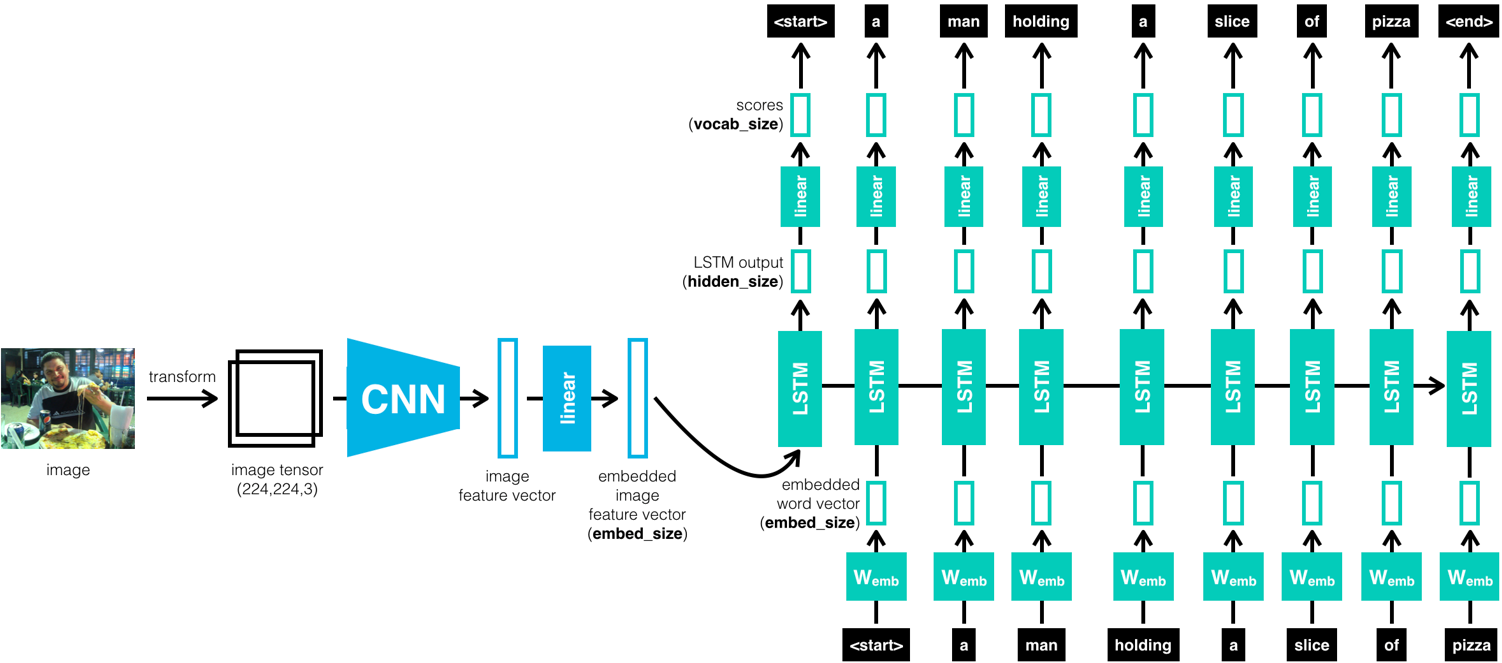

In [ ]:
#~~~~~~~~~~~~~~~~~~~

In [14]:
# 인코더
encoder_input = Input(shape=(1920,), name='image_features')
#encoder_input = Input(shape=(1024,), name='image_features')
encoder_hidden = Dense(256, activation='relu')(encoder_input)
encoder_output = Reshape((1, 256))(encoder_hidden)

encoder_model = Model(inputs=encoder_input, outputs=encoder_output, name='Encoder')
encoder_model.summary()

Model: "Encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_features (InputLayer)  [(None, 1920)]           0         
                                                                 
 dense (Dense)               (None, 256)               491776    
                                                                 
 reshape (Reshape)           (None, 1, 256)            0         
                                                                 
Total params: 491,776
Trainable params: 491,776
Non-trainable params: 0
_________________________________________________________________


RepeatVector(max_length)
- 이 함수는 2차원 텐서를 받아 3차원 텐서로 바꿉니다.
- 입력 벡터를 max_length번 반복해서 시퀀스로 만들어줘요.
- 예시: (batch_size, hidden_dim) → (batch_size, max_length, hidden_dim)
- 이건 디코더에 동일한 컨텍스트를 timestep마다 입력하려는 목적이다.

* 전체 동작 요약
    - 인코더 출력의 첫 timestep(또는 summary 벡터)을 추출해서
    - 그것을 디코더의 길이만큼 복제하여 디코더에 초기 입력으로 넣기 위한 준비


In [15]:
from tensorflow.keras.layers import RepeatVector
encoder_repeated = RepeatVector(max_length)(encoder_output[:, 0, :]) 

# 디코더
decoder_input = Input(shape=(max_length,), name='caption_input')
decoder_embed = Embedding(vocab_size, 256, mask_zero=True)(decoder_input)
decoder_concat_input = concatenate([encoder_repeated, decoder_embed], axis=-1)
decoder_lstm_output = LSTM(256, return_sequences=False)(decoder_concat_input)
decoder_output = Dense(vocab_size, activation='softmax')(decoder_lstm_output)

decoder_model = Model(inputs=[encoder_output, decoder_input], outputs=decoder_output, name='Decoder')
decoder_model.summary()

Model: "Decoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1, 256)]     0           []                               
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 256)         0           ['input_1[0][0]']                
 ingOpLambda)                                                                                     
                                                                                                  
 caption_input (InputLayer)     [(None, 40)]         0           []                               
                                                                                                  
 repeat_vector (RepeatVector)   (None, 40, 256)      0           ['tf.__operators__.getitem[

## 모델 설정

In [16]:
# 최종 모델
caption_model = Model(inputs=[encoder_input, decoder_input], outputs=decoder_output, name='Caption_model')
caption_model.summary()
caption_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "Caption_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_features (InputLayer)    [(None, 1920)]       0           []                               
                                                                                                  
 dense (Dense)                  (None, 256)          491776      ['image_features[0][0]']         
                                                                                                  
 reshape (Reshape)              (None, 1, 256)       0           ['dense[0][0]']                  
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 256)         0           ['reshape[0][0]']                
 ingOpLambda)                                                                         

## 모델 훈련

In [17]:
train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=16,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=16,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

In [18]:
train_generator[0][1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [19]:
history = caption_model.fit(
        train_generator,
        epochs=5,
        validation_data=validation_generator)

Epoch 1/5
2022/2022 [==============================] - 450s 221ms/step - loss: 4.8768 - accuracy: 0.1978 - val_loss: 4.0281 - val_accuracy: 0.2669
Epoch 2/5
2022/2022 [==============================] - 256s 127ms/step - loss: 3.6173 - accuracy: 0.3006 - val_loss: 3.6084 - val_accuracy: 0.3098
Epoch 3/5
2022/2022 [==============================] - 256s 126ms/step - loss: 3.1909 - accuracy: 0.3383 - val_loss: 3.4840 - val_accuracy: 0.3268
Epoch 4/5
2022/2022 [==============================] - 260s 129ms/step - loss: 2.9160 - accuracy: 0.3658 - val_loss: 3.4407 - val_accuracy: 0.3356
Epoch 5/5
2022/2022 [==============================] - 257s 127ms/step - loss: 2.7080 - accuracy: 0.3872 - val_loss: 3.4619 - val_accuracy: 0.3365


In [ ]:
!nvidia-smi

## 모델 예측

In [20]:
def predict_caption(model, image, tokenizer, max_length, features):
    
    # 이미지 특징을 인코더에 넣고 출력 생성
    feature = features[image]  
    feature = feature.reshape((1, 1920)) 
    encoder_output = encoder_model.predict(feature, verbose=0)

    in_text = ">>"

    # 캡션 생성
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        # 디코더에 입력: encoder_output과 padded sequence
        pred = decoder_model.predict([encoder_output, sequence], verbose=0)
        pred = np.argmax(pred)

        word = idx_to_word(pred, tokenizer)

        if word is None:
            break
        in_text += " " + word
        if word == '<<':
            break
    return in_text 

In [21]:
samples = test.sample(10)
samples.reset_index(drop=True,inplace=True)
samples['caption'] = ''

In [22]:
samples

,image,caption
0,3627076769_3b71e73018.jpg,
1,506367606_7cca2bba9b.jpg,
2,3677239603_95865a9073.jpg,
3,3677693858_62f2f3163f.jpg,
4,3729525173_7f984ed776.jpg,
5,3694093650_547259731e.jpg,
6,505062117_a70b4e10ab.jpg,
7,522063319_33827f1627.jpg,
8,369360998_ba56fb436f.jpg,
9,3713177334_32f3245fd8.jpg,


In [23]:
for index,record in samples.iterrows():    
    caption = predict_caption(caption_model, record['image'], tokenizer, max_length, features)
    print('-'*10+'>', caption)
    samples.loc[index,'caption'] = caption

----------> >> man in a blue shirt and a white shirt is sitting on a couch with a woman in a black shirt and a white shirt and a white shirt and a white shirt and a white shirt and a white
----------> >> man in a blue shirt is sitting on a table with a baby in a restaurant with a baby in his hand and a woman in a black shirt and a woman in a black shirt and a woman in
----------> >> man in a blue shirt is standing in front of a crowd of people in a crowd of people in the background holding a child in a blue shirt and a woman in a blue shirt and a white shirt
----------> >> man in blue shirt swinging on a swing set in the playground at the playground park in the background is swinging on the playground equipment in the background and a blue shirt and a blue shirt is jumping on the
----------> >> man and woman are standing on a wall with a statue of them in the background looking at a glass case and a woman in a white shirt and a white shirt and a white shirt is standing in front
-------

In [ ]:
record.shape

In [24]:
samples

,image,caption
0,3627076769_3b71e73018.jpg,>> man in a blue shirt and a white shirt is si...
1,506367606_7cca2bba9b.jpg,>> man in a blue shirt is sitting on a table w...
2,3677239603_95865a9073.jpg,>> man in a blue shirt is standing in front of...
3,3677693858_62f2f3163f.jpg,>> man in blue shirt swinging on a swing set i...
4,3729525173_7f984ed776.jpg,>> man and woman are standing on a wall with a...
5,3694093650_547259731e.jpg,>> man and woman are standing on a wall with a...
6,505062117_a70b4e10ab.jpg,>> man in a black collar swims in the water wi...
7,522063319_33827f1627.jpg,>> man in a blue shirt and a black hat with a ...
8,369360998_ba56fb436f.jpg,>> man in a red jacket is standing on the grou...
9,3713177334_32f3245fd8.jpg,>> man in a blue shirt and blue helmet is ridi...


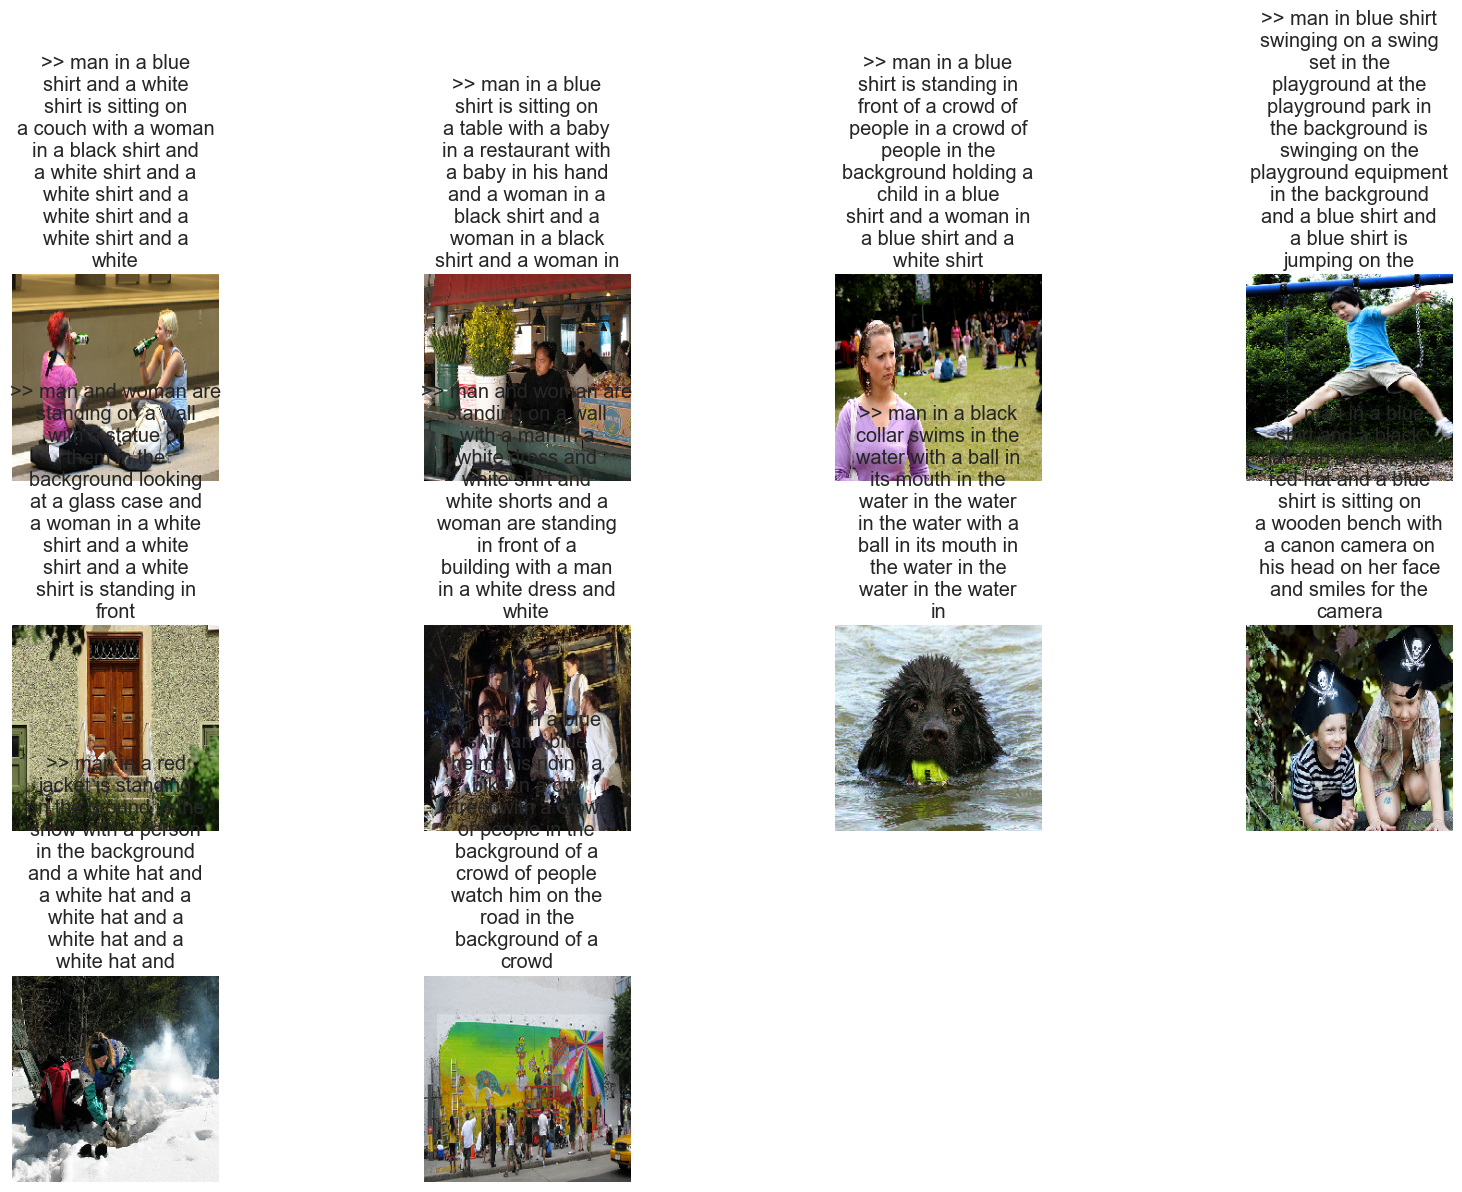

In [38]:
display_images(samples)

## 모델 평가